### 문서 유사도 (Document Similarity)
두 문서가 내용적으로 얼마나 비슷한지를 수치로 나타낸다.  
보통 문서를 벡터(TF-IDF 등) 로 바꾼 뒤, 벡터 간 거리를/각도를 계산해서 유사도를 구한다.

In [3]:
# 파이썬에서 사용하는 문장부호 목록
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [2]:
import numpy as np
import pandas as pd
import os, glob

path = './data/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path, '*.data'))

filename_list = []  # 파일명
opinions_list = []  # 파일 내용(의견)

for file_ in all_files:
    df = pd.read_table(
        file_,              # 경로
        header= None,       # 첫 줄은 컬럼명으로 사용안함
        index_col= None,    # 인덱스 컬럼 지정 안함(기본)
        encoding= 'latin1'  # 특수문자 깨짐방지
    )
    # display(df)
    
    filename = os.path.basename(file_)  # 파일명 추출
    filename = filename.split('.')[0]   # 확장자 제거
    filename_list.append(filename)      # 파일명 리스트 추가
    
    opinions = df.to_string(index=False, header=False) # 인덱스/ 헤더 제거
    opinions_list.append(opinions)

In [4]:
document_df = pd.DataFrame({
    'filename' : filename_list,
    'opinions' : opinions_list
})

document_df

,filename,opinions
0,accuracy_garmin_nuvi_255W_gps,...
1,bathroom_bestwestern_hotel_sfo,...
2,battery-life_amazon_kindle,...
3,battery-life_ipod_nano_8gb,...
4,battery-life_netbook_1005ha,...
5,buttons_amazon_kindle,...
6,comfort_honda_accord_2008,...
7,comfort_toyota_camry_2007,...
8,directions_garmin_nuvi_255W_gps,...
9,display_garmin_nuvi_255W_gps,...


In [9]:
import nltk

nltk.download('wordnet')        # 대형 의미 사전

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\MoonSungHo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
from nltk.stem import WordNetLemmatizer     # 표제어(lemma) 추출 도구

lemmatizer = WordNetLemmatizer()
print(lemmatizer.lemmatize('running', pos= 'v'))    # 동사로 간주해 표제어(사전 대표 기본형) 변환
print(lemmatizer.lemmatize('ran', pos= 'v'))        

run
run


In [15]:
def lemmatizer(text):
    text = text.lower()     # 소문자 변환
    
    punc_rem_dict = dict((ord(ch), None) for ch in string.punctuation)  # 문장부포 제거용 치환 딕셔너리
    text = text.translate(punc_rem_dict)    # text 에서 문장부호에 해당하는 것들은 None 
    
    tokens = nltk.word_tokenize(text)
    
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token, pos= 'v') for token in tokens]

In [18]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokenizer(text):
    tokens = word_tokenize(text)
    return [lemmatizer.lemmatize(token) for token in tokens]

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    tokenizer= lemmatize_tokenizer,      # 사용자 정의 토크나이저 적용
    stop_words= 'english',      # 영어 불용어 제거
    ngram_range= (1,2),         # 유니그램, 
    max_df= 0.85,               # 전체 문서 85% 등장시 흔한 단어이므로 제외
    min_df= 0.05                # 전체 문서 5% 등장시 
)

opinions_vecs = tfidf_vectorizer.fit_transform(document_df['opinions'])
print(opinions_vecs.toarray().shape)    # 문서수, 특성 수 
print(opinions_vecs)                    # 희소행렬 출력

c:\Users\MoonSungHo\skn34-st\study\DL\DL_venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\MoonSungHo\skn34-st\study\DL\DL_venv\Lib\site-packages\sklearn\feature_extraction\text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


(51, 5876)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 36428 stored elements and shape (51, 5876)>
  Coords	Values
  (0, 1153)	0.7042986557830511
  (0, 2692)	0.08192192532037257
  (0, 4956)	0.014672888662146897
  (0, 4311)	0.03151513522544696
  (0, 2166)	0.13860792463385038
  (0, 3147)	0.02120882245581105
  (0, 2668)	0.012600720421259126
  (0, 3335)	0.012961392260219279
  (0, 1403)	0.0137558056766464
  (0, 3696)	0.025922784520438558
  (0, 4697)	0.016954010646926483
  (0, 5112)	0.011939009829872971
  (0, 3552)	0.017879520774442288
  (0, 4144)	0.016384385064074514
  (0, 2686)	0.016384385064074514
  (0, 3066)	0.016384385064074514
  (0, 1241)	0.01988128271051937
  (0, 4659)	0.042590080551662544
  (0, 3953)	0.01519054225583574
  (0, 3595)	0.16140177528361585
  (0, 4292)	0.01575756761272348
  (0, 81)	0.03830379861778345
  (0, 5490)	0.04506082450279024
  (0, 2782)	0.19661262076889413
  (0, 5447)	0.06481423150437256
  :	:
  (50, 4326)	0.023986459297498645
  (50, 5454)	0.01199

In [21]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters= 4,
    max_iter= 5000,
    random_state= 0
)

opinions_label = kmeans.fit_predict(opinions_vecs)
document_df['cluster'] = opinions_label
document_df

,filename,opinions,cluster
0,accuracy_garmin_nuvi_255W_gps,...,2
1,bathroom_bestwestern_hotel_sfo,...,1
2,battery-life_amazon_kindle,...,0
3,battery-life_ipod_nano_8gb,...,2
4,battery-life_netbook_1005ha,...,2
5,buttons_amazon_kindle,...,0
6,comfort_honda_accord_2008,...,3
7,comfort_toyota_camry_2007,...,3
8,directions_garmin_nuvi_255W_gps,...,2
9,display_garmin_nuvi_255W_gps,...,2


In [22]:
# 기준 리뷰(호텔 클러스터 1) 인덱스 확인 및 기준 문서 선택
hotel_idx = document_df[document_df['cluster']==1].index
print(hotel_idx.shape)
print(hotel_idx)

(16,)
Index([1, 13, 14, 15, 20, 21, 24, 28, 30, 31, 32, 38, 39, 40, 45, 46], dtype='int64')


In [14]:
base_idx = 1    # 기준 리뷰 인덱스
document_df.iloc[base_idx]  # 기준리뷰 확인

filename                       bathroom_bestwestern_hotel_sfo
opinions                                                  ...
Name: 1, dtype: str

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

# 기준 리뷰 vs 전체 리뷰 코사인 유사도 계산
opinions_sim = cosine_similarity(opinions_vecs[base_idx], opinions_vecs)
opinions_sim

array([[0.00822885, 1.        , 0.00885892, 0.00619981, 0.0084505 ,
        0.01106629, 0.03309902, 0.04041862, 0.00710606, 0.00712044,
        0.01077919, 0.00931981, 0.01109823, 0.04134512, 0.05417675,
        0.05944797, 0.00745318, 0.01777375, 0.01377118, 0.01802893,
        0.05850038, 0.0595259 , 0.00692543, 0.00905992, 0.0364343 ,
        0.00977714, 0.01175118, 0.02022842, 0.11239675, 0.00508419,
        0.3768672 , 0.32475842, 0.51612444, 0.00796922, 0.00957893,
        0.01792997, 0.01989043, 0.0152597 , 0.11158612, 0.13179641,
        0.13975033, 0.04203361, 0.00858931, 0.00346198, 0.0120624 ,
        0.09203591, 0.06930576, 0.00610159, 0.00657972, 0.00858896,
        0.00627839]])

In [ ]:
# 기준 리뷰와 코사인 유사도가 가장 높은 무서들을 df으로 정렬해서 확인
# 유사도 내림차순 정렬 후 결과 DataFrame 생성
opinions_sorted_idx = opinions_sim.argsort()[:, ::-1]       # 유사도 큰 순서로 인덱스 정렬
opinions_sorted_idx = opinions_sorted_idx[:, 1:]            # 자기 자신(유사도 1 가장높음) 인덱스 제외
opinions_sorted_idx = opinions_sorted_idx.reshape(-1)       # 인덱스 배열을 1차원 형태로 반환

# 유사도가 높은 순으로 정렬된 파일명 조회
# 정렬된 상태의 filename, cluster 만 추출
result_df = document_df.iloc[opinions_sorted_idx][['filename','cluster']]  
opinions_sim = opinions_sim.reshape(-1)     # 유사도 배열도 1차원으로 변환       

result_df['similarity'] = opinions_sim[opinions_sorted_idx]     # 가장 유사도 높은 순서의 값을 컬럼으로 추가
result_df

,filename,cluster,similarity
32,room_holiday_inn_london,1,0.516124
30,rooms_bestwestern_hotel_sfo,1,0.376867
31,rooms_swissotel_chicago,1,0.324758
40,service_swissotel_hotel_chicago,1,0.139750
39,service_holiday_inn_london,1,0.131796
28,price_holiday_inn_london,1,0.112397
38,service_bestwestern_hotel_sfo,1,0.111586
45,staff_bestwestern_hotel_sfo,1,0.092036
46,staff_swissotel_chicago,1,0.069306
21,location_holiday_inn_london,1,0.059526


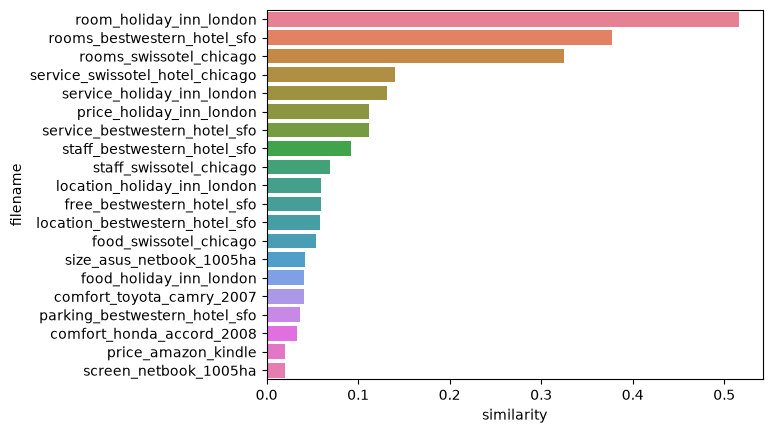

In [ ]:
# 유사도 기준 상위 20개 막대그래프 시각화
import matplotlib.pyplot as plt 
import seaborn as sns

sns.barplot(
    x = 'similarity',           # x = 유사도
    y = 'filename',             # y = 파일명
    data = result_df.iloc[:20], # 상위 20개
    hue = 'filename'            # 색상구분
)

plt.show()